# Mustang: user-resampled traces for Greenfilling

This notebook generates a reproducible set of Mustang workloads for **Greenfilling experiments**. The goal is to create traces with a larger share of long and wide jobs without fabricating individual jobs.

The resampling unit is a complete source-user subtrace. When a source user is selected, all of that user's replay jobs are copied with their original attributes, submission times, and within-user timing. Only the probability of selecting each source user changes. The original warm-up context remains fixed.

The workflow is: validate the source data, calibrate a heavy-user rule, generate the trace collection, verify the persisted artifacts, compare the candidates, and export one workload for the Greenfilling campaign.

The method adapts the user-based resampling idea of [Zakay and Feitelson (ICPE 2013)](https://research.spec.org/icpe_proceedings/2013/proceedings/p149.pdf) to fixed four-week Mustang slack and stress windows. It does not model users reacting to congestion.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_repository_root(start):
    for candidate in [start, *start.parents]:
        if (candidate / "analysis" / "mustang_user_resampling_analysis.py").is_file():
            return candidate
    raise FileNotFoundError(
        "Run this notebook from inside the experimental-artifacts checkout."
    )


ROOT = find_repository_root(Path.cwd().resolve())
ANALYSIS_DIR = ROOT / "analysis"
WORKLOAD_DIR = ROOT / "workloads and platforms"
ARTIFACT_DIR = ANALYSIS_DIR / "mustang_user_resampling_artifacts"
FIGURE_DIR = ANALYSIS_DIR / "figures"
if str(ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_DIR))

import mustang_user_resampling_analysis as mura

pd.set_option("display.max_columns", 120)
mura.configure_plot_style()

ROOT, ARTIFACT_DIR, FIGURE_DIR


(PosixPath('/home/brunolim4/coding/pibic/experimental-artifacts'),
 PosixPath('/home/brunolim4/coding/pibic/experimental-artifacts/analysis/mustang_user_resampling_artifacts'),
 PosixPath('/home/brunolim4/coding/pibic/experimental-artifacts/analysis/figures'))

## Configure the trace collection

The configuration below fixes the parts of the experiment that do not depend on heavy-user classification: source windows, scenario weights, random seeds, platform size, and output paths.

With the default configuration, the notebook produces one original workload and twenty synthetic workloads for each regime: five uniform-resampling replicas and five replicas at each of the three heavy-user weights. The next sections choose the three classification parameters from the source data. If a parameter changes, rerun this cell and every cell below it.

In [2]:
SOURCE_CSV = WORKLOAD_DIR / "datasets" / "mustang.csv"
REGIMES = {
    "slack": ("2015-04-13", "2015-05-11"),
    "stress": ("2013-01-07", "2013-02-04"),
}
SCENARIO_WEIGHTS = {
    "random": 1.0,
    "heavy_2x": 2.0,
    "heavy_4x": 4.0,
    "heavy_8x": 8.0,
}
SEEDS = [20260926, 20260927, 20260928, 20260929, 20260930]

planned_synthetic = len(REGIMES) * len(SCENARIO_WEIGHTS) * len(SEEDS)
generation_scope = pd.DataFrame(
    {
        "Value": [
            "; ".join(f"{name}: {start} to {end}" for name, (start, end) in REGIMES.items()),
            ", ".join(f"{name}: {weight:g}x" for name, weight in SCENARIO_WEIGHTS.items()),
            ", ".join(map(str, SEEDS)),
            f"{len(REGIMES)} baselines + {planned_synthetic} synthetic workloads",
        ]
    },
    index=["Replay windows", "Sampling weights", "Seeds", "Planned collection"],
)
display(generation_scope)
print(f"Generated traces: {ARTIFACT_DIR.relative_to(ROOT)}")
print(f"Publication figures: {FIGURE_DIR.relative_to(ROOT)}")

,Value
Replay windows,slack: 2015-04-13 to 2015-05-11; stress: 2013-...
Sampling weights,"random: 1x, heavy_2x: 2x, heavy_4x: 4x, heavy_..."
Seeds,"20260926, 20260927, 20260928, 20260929, 20260930"
Planned collection,2 baselines + 40 synthetic workloads


Generated traces: analysis/mustang_user_resampling_artifacts
Publication figures: analysis/figures


## Validate the source data

Before generating workloads, the notebook reloads the full Mustang CSV and applies the same eligibility rules used by the existing Mustang workflow:

- the job has a valid user ID and valid submission and execution times;
- `0 < node_count <= 1600`;
- real runtime is at least one second; and
- requested walltime is at least the real runtime.

A row may fail more than one rule, so the diagnostic reason counts do not need to add up to the total number of excluded rows. The notebook then reconstructs the original slack and stress extracts from the eligible rows. This establishes the baselines that every generated workload is checked against.

In [3]:
source, hygiene = mura.load_source(SOURCE_CSV, REGIMES)
display(mura.format_hygiene_summary(hygiene))


,Rows
Validation check,
Source rows,2113175
Eligible execution rows,1990377
Excluded rows,122798
Rows with invalid node count,28833
Rows with invalid user ID,0
Rows with invalid execution times,94170
Rows with invalid submission times,94173
Runtimes raised to 1 second,673
Rows using runtime as walltime,0


## Inspect the original job shapes

First inspect what the two source regimes contain. The upper plots show the runtime and node-count distributions. The lower plots show how runtime and node count occur together.

The two-hour and 160-node reference lines are descriptive: they separate long and wide jobs in the later comparison plots. They do **not** define heavy users. Heavy-user classification is based on job node-hours and is calibrated in the next section.

,Replay jobs,Runtime P50 [h],Runtime P90 [h],Runtime P99 [h],Nodes P50,Nodes P90,Nodes P99,Jobs >2 h [%],Jobs >=160 nodes [%],Both [%]
Regime,,,,,,,,,,
Slack,10683,0.53,14.37,16.0,5.0,63.0,204.5,38.99,2.55,1.52
Stress,5089,0.04,12.56,16.0,4.0,86.0,450.0,26.59,4.62,2.87


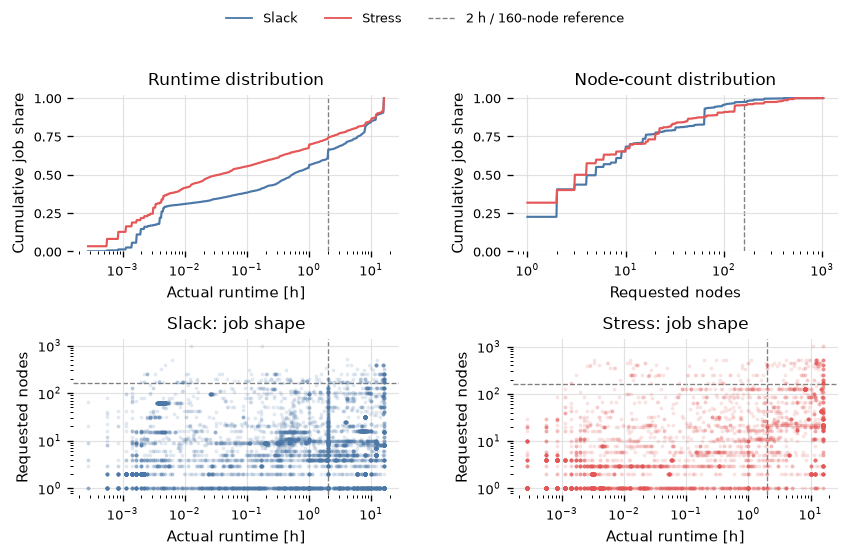

Saved PDF and 600 dpi PNG in analysis/figures/.


In [4]:
source_pools = {
    regime: mura.source_replay_pool(source, bounds)
    for regime, bounds in REGIMES.items()
}
source_job_summary = mura.summarize_source_job_distributions(source_pools)
display(mura.format_source_job_summary(source_job_summary))

source_job_figure = mura.plot_source_job_distributions(
    source_pools, figure_dir=FIGURE_DIR
)
display(source_job_figure)
plt.close(source_job_figure)
print("Saved PDF and 600 dpi PNG in analysis/figures/.")


## Define heavy users in three steps

A source user is heavy only if they repeatedly submit high-node-hour jobs. The rule therefore needs three parameters:

1. `HIGH_JOB_THRESHOLD_QUANTILE`: which jobs count as high node-hours;
2. `MIN_JOBS_FOR_HEAVY`: how much user history is required; and
3. `HEAVY_USER_THRESHOLD_QUANTILE`: how large a high-job share makes an eligible user heavy.

Each parameter gets one calibration plot. The code cell immediately after the plot sets the current value and reports its exact effect.

### 1. Define a high-node-hour job

For each replay job, compute

$$
\text{job node-hours} = \text{node count} \times \frac{\text{runtime in seconds}}{3600}.
$$

At each candidate percentile, the chart shows the composition of the jobs above the corresponding node-hour threshold. Each vertical slice adds to 100% and separates jobs that are long, wide, both, or neither according to the descriptive reference lines.

Moving right makes the high-job definition stricter. The plot is a decision aid; the next cell sets the percentile actually used by the generator.

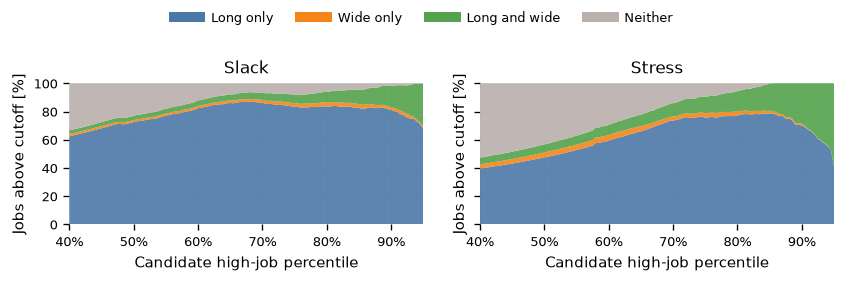

In [5]:
job_threshold_figure = mura.plot_job_threshold_decision(
    source_pools, figure_dir=FIGURE_DIR
)
display(job_threshold_figure)
plt.close(job_threshold_figure)


Set `HIGH_JOB_THRESHOLD_QUANTILE` below. A job is high when its node-hours are **strictly greater** than the regime-specific quantile.

After changing the value, inspect the table to confirm the resulting threshold, number of high jobs, and long/wide composition in both regimes.

In [6]:
# Classification choice 1: job-level work cutoff.
HIGH_JOB_THRESHOLD_QUANTILE = 0.70

job_cutoff_rows = []
for regime, pool in source_pools.items():
    threshold = pool["node_hours"].quantile(
        HIGH_JOB_THRESHOLD_QUANTILE, interpolation="linear"
    )
    high_jobs = pool["node_hours"].gt(threshold)
    job_cutoff_rows.append(
        {
            "Regime": regime.title(),
            "Selected percentile": f"P{100 * HIGH_JOB_THRESHOLD_QUANTILE:.0f}",
            "Threshold [node-h]": threshold,
            "Jobs above threshold": int(high_jobs.sum()),
            "High jobs [%]": 100 * high_jobs.mean(),
        }
    )

job_cutoff_summary = pd.DataFrame(job_cutoff_rows).set_index("Regime")
display(job_cutoff_summary.round(2))

,Selected percentile,Threshold [node-h],Jobs above threshold,High jobs [%]
Regime,,,,
Slack,P70,15.79,3205,30.00
Stress,P70,12.53,1527,30.01


### 2. Require enough user history

A high-job share based on only a few jobs is unstable. This chart shows what remains as the minimum-history requirement increases: eligible source users, their share of replay jobs, and their share of total node-hours.

Moving right gives stronger evidence about each user's typical behavior, but excludes more users from heavy-user classification. The excluded users are still available for resampling; they simply keep the ordinary sampling weight.

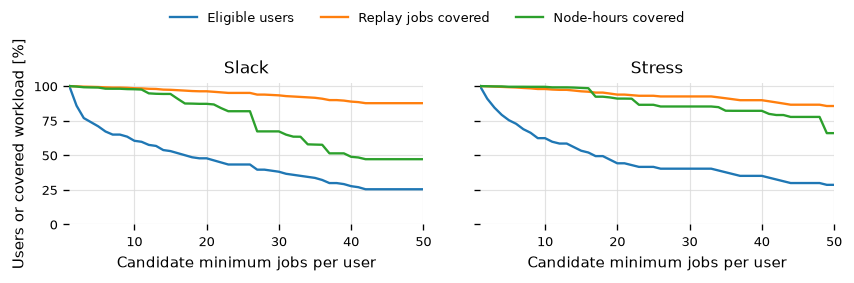

In [7]:
minimum_jobs_figure = mura.plot_minimum_jobs_decision(
    source_pools, figure_dir=FIGURE_DIR
)
display(minimum_jobs_figure)
plt.close(minimum_jobs_figure)


Set `MIN_JOBS_FOR_HEAVY` below. A user must have at least this many replay jobs in the regime to be eligible for heavy classification.

The table reports the exact number of eligible users and how much of the source workload they represent. Use it to check that the chosen minimum provides enough history without discarding most of the population from classification.

In [8]:
# Classification choice 2: minimum evidence required from a source user.
MIN_JOBS_FOR_HEAVY = 15

eligibility_rows = []
for regime, pool in source_pools.items():
    job_counts = pool.groupby("source_user_ID").size()
    eligible = job_counts.ge(MIN_JOBS_FOR_HEAVY)
    eligibility_rows.append(
        {
            "Regime": regime.title(),
            "Minimum jobs": MIN_JOBS_FOR_HEAVY,
            "Source users": len(job_counts),
            "Eligible users": int(eligible.sum()),
            "Eligible users [%]": 100 * eligible.mean(),
            "Replay jobs from eligible users [%]": (
                100 * job_counts.loc[eligible].sum() / job_counts.sum()
            ),
        }
    )

eligibility_summary = pd.DataFrame(eligibility_rows).set_index("Regime")
display(eligibility_summary.round(2))

,Minimum jobs,Source users,Eligible users,Eligible users [%],Replay jobs from eligible users [%]
Regime,,,,,
Slack,15,134,71,52.99,97.31
Stress,15,77,41,53.25,96.23


### 3. Choose the heavy tail among eligible users

For every eligible user, compute

$$
\text{high-job share}_u = \frac{\text{high-node-hour jobs submitted by }u}{\text{replay jobs submitted by }u}.
$$

The upper row shows the expected long-job and wide-job shares after applying each candidate heavy-user percentile and sampling weight. The dashed line is the original regime. The lower row shows how many eligible users would be labeled heavy at the same percentile.

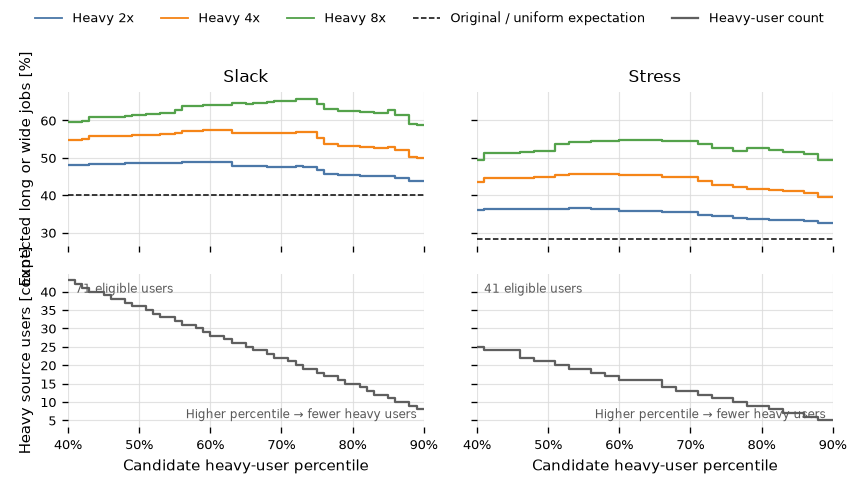

In [9]:
calibration_profiles = {
    regime: mura.measure_user_activity(
        pool,
        job_node_hours_quantile=HIGH_JOB_THRESHOLD_QUANTILE,
        min_jobs_for_heavy=MIN_JOBS_FOR_HEAVY,
    )
    for regime, pool in source_pools.items()
}

heavy_user_decision = mura.plot_heavy_user_decision(
    source_pools,
    calibration_profiles,
    SCENARIO_WEIGHTS,
    figure_dir=FIGURE_DIR,
)
display(heavy_user_decision)
plt.close(heavy_user_decision)


Set `HEAVY_USER_THRESHOLD_QUANTILE` below. Among eligible users, a user is heavy when their high-job share is greater than or equal to the regime-specific quantile.

The first table reports the actual classification. The second shows the expected workload composition under each sampling scenario before any random draw is made. `Effective source users` is $1 / \sum_u p_u^2$: it summarizes how concentrated the sampling probabilities are, with smaller values indicating that fewer source users dominate the draws.

In [10]:
# Classification choice 3: upper tail of consistent high-job submitters.
HEAVY_USER_THRESHOLD_QUANTILE = 0.50

calibrated_users = {
    regime: mura.characterize_users(
        pool,
        job_node_hours_quantile=HIGH_JOB_THRESHOLD_QUANTILE,
        min_jobs_for_heavy=MIN_JOBS_FOR_HEAVY,
        heavy_user_threshold_quantile=HEAVY_USER_THRESHOLD_QUANTILE,
    )
    for regime, pool in source_pools.items()
}

calibrated_profile_table = pd.concat(
    [users.reset_index().assign(regime=regime) for regime, users in calibrated_users.items()],
    ignore_index=True,
)
classification_summary = mura.summarize_user_classification(calibrated_profile_table)
display(mura.format_user_classification(classification_summary))

selected_impact = pd.concat(
    [
        mura.expected_resampling_metrics(
            source_pools[regime], users,
            HEAVY_USER_THRESHOLD_QUANTILE, SCENARIO_WEIGHTS,
        ).assign(regime=regime)
        for regime, users in calibration_profiles.items()
    ],
    ignore_index=True,
)
display(mura.format_expected_resampling_metrics(selected_impact))

,Replay jobs,Source users,Eligible users,Heavy users,High-job percentile,High-job threshold [node-h],Minimum jobs,User threshold percentile,Required high-job share [%],Nominal upper tail [%]
Regime,,,,,,,,,,
Slack,10683,134,71,36,70.0,15.79,15,50.0,33.33,50.0
Stress,5089,77,41,21,70.0,12.53,15,50.0,45.83,50.0


Expected heavy draws [%]  Expected long jobs [%]  \
Regime Scenario                                                     
Slack  Random                       26.87                   38.99   
       Heavy 2x                     42.35                   47.16   
       Heavy 4x                     59.50                   54.38   
       Heavy 8x                     74.61                   59.57   
Stress Random                       27.27                   26.59   
       Heavy 2x                     42.86                   34.39   
       Heavy 4x                     60.00                   42.63   
       Heavy 8x                     75.00                   49.55   

                 Expected wide jobs [%]  Expected long or wide jobs [%]  \
Regime Scenario                                                           
Slack  Random                      2.55                           40.02   
       Heavy 2x                    3.46                           48.55   
       Heavy 4x                    4.26                           56.10   
       Heavy 8x                    4.84                           61.52   
Stress Random                      4.62                           28.34   
       Heavy 2x                    5.60                           36.33   
       Heavy 4x                    6.63                           44.76   
       Heavy 8x                    7.50                           51.85   

                 Expected node-hours / original [%]  \
Regime Scenario                                       
Slack  Random                                100.00   
       Heavy 2x                              147.96   
       Heavy 4x                              201.08   
       Heavy 8x                              247.87   
Stress Random                                100.00   
       Heavy 2x                              135.03   
       Heavy 4x                              173.56   
       Heavy 8x                              207.28   

                 Effective user diversity [%]  
Regime Scenario                                
Slack  Random                          100.00  
       Heavy 2x                         89.12  
       Heavy 4x                         64.84  
       Heavy 8x                         46.29  
Stress Random                          100.00  
       Heavy 2x                         89.09  
       Heavy 4x                         64.94  
       Heavy 8x                         46.55

## Translate heavy labels into sampling probabilities

Every source user remains in the sampling population. In a heavy-weight scenario, heavy users receive weight $w$ and all other users receive weight 1:

$$
p_u = \frac{w_u}{\sum_v w_v}.
$$

Each synthetic workload draws exactly as many users as were active in the original regime, with replacement. A selected user contributes their complete replay subtrace. If the same source user is drawn twice, the two copies receive different synthetic user IDs.

The table below describes the expected mixture before sampling.

In [11]:
prepared = {}
expected_rows = []
profile_tables = []

for regime, bounds in REGIMES.items():
    reference = json.loads((WORKLOAD_DIR / f"mustang_{regime}.json").read_text())
    pool, context = mura.prepare_regime(source, reference, bounds)
    users = mura.characterize_users(
        pool,
        job_node_hours_quantile=HIGH_JOB_THRESHOLD_QUANTILE,
        min_jobs_for_heavy=MIN_JOBS_FOR_HEAVY,
        heavy_user_threshold_quantile=HEAVY_USER_THRESHOLD_QUANTILE,
    )
    pd.testing.assert_series_equal(
        users["is_heavy"].sort_index(),
        calibrated_users[regime]["is_heavy"].sort_index(),
    )
    prepared[regime] = (pool, context, users, reference)
    profile_tables.append(users.reset_index().assign(regime=regime))
    for scenario, weight in SCENARIO_WEIGHTS.items():
        weights = np.where(users["is_heavy"], weight, 1.0)
        expected_rows.append(
            {
                "regime": regime,
                "scenario": scenario,
                "expected_heavy_user_share": np.average(users["is_heavy"], weights=weights),
                "expected_jobs": len(users) * np.average(users["jobs"], weights=weights),
                "expected_node_hours": len(users) * np.average(
                    users["total_node_hours"], weights=weights
                ),
            }
        )

source_user_profiles = pd.concat(profile_tables, ignore_index=True)
expected_composition = pd.DataFrame(expected_rows)
display(mura.format_expected_composition(expected_composition))

Expected heavy draws [%]  Expected replay jobs  \
Regime Scenario                                                   
Slack  Random                       26.87              10683.00   
       Heavy 2x                     42.35              11969.35   
       Heavy 4x                     59.50              13393.91   
       Heavy 8x                     74.61              14648.70   
Stress Random                       27.27               5089.00   
       Heavy 2x                     42.86               5192.79   
       Heavy 4x                     60.00               5306.95   
       Heavy 8x                     75.00               5406.84   

                 Expected node-hours  
Regime Scenario                       
Slack  Random              927969.08  
       Heavy 2x           1373053.66  
       Heavy 4x           1865957.24  
       Heavy 8x           2300121.02  
Stress Random             1045284.47  
       Heavy 2x           1411435.92  
       Heavy 4x           1814202.52  
       Heavy 8x           2166623.29

## Generate the trace collection

This cell writes the complete collection to the configured output directory:

- one validated original workload per regime;
- five uniform-resampling replicas per regime;
- five replicas for each configured heavy-user weight per regime; and
- `manifest.csv`, `summary.csv`, `user_profiles.csv`, and generation metadata.

Each CSV preserves the nine Mustang columns and contains the four-week replay jobs. Each Batsim JSON uses 1,600 resources, reconstructs the same profiles as the existing Mustang workflow, and includes the original warm-up jobs unchanged. Stable sorting makes submission-time ties reproducible.

Generation stops if IDs collide, a job is invalid, a profile reference is missing, provenance is incomplete, or a baseline differs semantically from the existing Mustang workload.

In [12]:
summary, manifest, user_profiles, replays = mura.generate_artifacts(
    source=source,
    workload_dir=WORKLOAD_DIR,
    output_dir=ARTIFACT_DIR,
    regimes=REGIMES,
    job_node_hours_quantile=HIGH_JOB_THRESHOLD_QUANTILE,
    min_jobs_for_heavy=MIN_JOBS_FOR_HEAVY,
    heavy_user_threshold_quantile=HEAVY_USER_THRESHOLD_QUANTILE,
    scenario_weights=SCENARIO_WEIGHTS,
    seeds=SEEDS,
    source_path=SOURCE_CSV,
    hygiene=hygiene,
)

inventory = (
    summary.groupby(["regime", "scenario"], sort=False)
    .size()
    .rename("workloads")
    .unstack(fill_value=0)
)
display(inventory)
print(f"Generated and validated {len(summary)} CSV/JSON workload pairs.")


slack: 10,683 original jobs, 134 users (36 heavy); 21 CSV/JSON pairs validated


stress: 5,089 original jobs, 77 users (21 heavy); 21 CSV/JSON pairs validated


scenario,original,random,heavy_2x,heavy_4x,heavy_8x
regime,,,,,
slack,1,5,5,5,5
stress,1,5,5,5,5


Generated and validated 42 CSV/JSON workload pairs.


## Verify the persisted collection

The verification step reloads the files from disk instead of trusting in-memory objects. It checks the CSV schema, synthetic IDs, job validity, Batsim resources and profile references, unchanged warm-up jobs, baseline equivalence, and complete seed and provenance records.

It also reconstructs every user draw from the saved seed and weights. This confirms that each named workload is reproducible and that its random stream does not depend on loop or dictionary order.

In [13]:
verification = mura.verify_artifacts(ARTIFACT_DIR, WORKLOAD_DIR)
display(pd.Series(verification, name="verified").to_frame())

for regime, (pool, _, users, _) in prepared.items():
    for scenario, weight in reversed(list(SCENARIO_WEIGHTS.items())):
        for seed in reversed(SEEDS):
            replay_again, _ = mura.resample(pool, users, regime, scenario, weight, seed)
            stem = f"mustang_{regime}_{scenario}_seed{seed}"
            pd.testing.assert_frame_equal(replay_again, replays[stem])

print("All stochastic workloads reproduced exactly in reverse execution order.")


,verified
workloads_verified,42
synthetics,40
baselines,2
user_draws_verified,4431


All stochastic workloads reproduced exactly in reverse execution order.


## Compare the generated workloads

The summary table first reports the mean and standard deviation across the five replicas in each scenario. Use the interactive views below to inspect individual workloads.

The overview is one bubble chart with a Slack/Stress selector. Each point is one workload: x is the long-job share, y is the wide-job share, bubble area increases with total node-hours, and color identifies the sampling scenario. Hover over a point to see its workload ID, seed, heavy-user draws, source concentration, and hourly-arrival correlation.

The distribution dashboard has one selector for all 42 workload IDs. It overlays the selected workload and the matching original baseline in five synchronized views: runtime, node count, daily submissions, synthetic-instance concentration, and source-user concentration. Hover and zoom are available in every panel.

In [14]:
display(mura.format_collection_summary(summary))
display(mura.format_manifest_preview(manifest))

trace_overview = mura.plot_interactive_trace_overview(summary)
display(trace_overview)

distribution_dashboard = mura.plot_interactive_trace_distributions(summary, replays)
display(distribution_dashboard)


Workloads  Replay jobs (mean)  Replay jobs (min)  \
Regime Scenario                                                     
Slack  Original          1             10683.0              10683   
       Random            5              9875.4               9104   
       Heavy 2x          5             10976.4               8362   
       Heavy 4x          5             11934.6               8406   
       Heavy 8x          5             14547.8              11878   
Stress Original          1              5089.0               5089   
       Random            5              4327.0               2837   
       Heavy 2x          5              5109.8               4313   
       Heavy 4x          5              5500.2               3749   
       Heavy 8x          5              5535.6               4650   

                 Replay jobs (max)  Node-hours (mean)  Heavy draws [%]  \
Regime Scenario                                                          
Slack  Original              10683          927969.08            26.87   
       Random                11555          968065.46            28.06   
       Heavy 2x              12691         1401354.68            42.24   
       Heavy 4x              14508         1618180.25            56.27   
       Heavy 8x              17670         2165998.20            72.39   
Stress Original               5089         1045284.47            27.27   
       Random                 6447         1040449.72            25.45   
       Heavy 2x               7351         1565835.12            49.09   
       Heavy 4x               9500         1676084.40            61.82   
       Heavy 8x               6959         2232243.21            73.51   

                 Wide jobs [%]  Long jobs [%]  Hourly submission Pearson r  \
Regime Scenario                                                              
Slack  Original           2.55          38.99                         1.00   
       Random             2.96          43.52                         0.76   
       Heavy 2x           3.89          51.30                         0.61   
       Heavy 4x           4.60          55.28                         0.60   
       Heavy 8x           4.67          60.79                         0.54   
Stress Original           4.62          26.59                         1.00   
       Random             4.85          33.32                         0.76   
       Heavy 2x           6.68          41.10                         0.64   
       Heavy 4x           7.03          42.70                         0.63   
       Heavy 8x           7.94          51.20                         0.57   

                 Work / capacity  Validated  
Regime Scenario                              
Slack  Original             0.86       True  
       Random               0.90       True  
       Heavy 2x             1.30       True  
       Heavy 4x             1.51       True  
       Heavy 8x             2.01       True  
Stress Original             0.97       True  
       Random               0.97       True  
       Heavy 2x             1.46       True  
       Heavy 4x             1.56       True  
       Heavy 8x             2.08       True

,Workload,Synthetic user,Source user,Jobs,High jobs,High jobs [%],Eligible,Heavy,Weight,Draw probability,Seed
0,mustang_slack_original,1,1,165,134,81.21,True,True,1.0,Identity,Baseline
134,mustang_slack_random_seed20260926,1,65,83,55,66.27,True,True,1.0,0.75%,20260926
804,mustang_slack_heavy_2x_seed20260926,1,65,83,55,66.27,True,True,2.0,1.18%,20260926
1474,mustang_slack_heavy_4x_seed20260926,1,143,40,31,77.50,True,True,4.0,1.65%,20260926
2144,mustang_slack_heavy_8x_seed20260926,1,1,165,134,81.21,True,True,8.0,2.07%,20260926
2814,mustang_stress_original,12,12,16,12,75.00,True,True,1.0,Identity,Baseline
2891,mustang_stress_random_seed20260926,1,104,33,11,33.33,True,False,1.0,1.30%,20260926
3276,mustang_stress_heavy_2x_seed20260926,1,86,157,116,73.89,True,True,2.0,2.04%,20260926
3661,mustang_stress_heavy_4x_seed20260926,1,98,74,71,95.95,True,True,4.0,2.86%,20260926
4046,mustang_stress_heavy_8x_seed20260926,1,197,142,92,64.79,True,True,8.0,3.57%,20260926


## Check the arrival pattern and choose a candidate

For each workload, align its 672 hourly submission counts with the original regime and compute their Pearson correlation:

$$
r = \operatorname{corr}(\text{candidate hourly counts}, \text{original hourly counts}).
$$

A value near 1 means that busy and quiet hours occur in a similar pattern.

The table lists every workload ID and its correlation. Use the dropdown in the hourly chart to overlay one candidate on its original baseline; hover for exact counts, zoom into a time interval, or use the range slider.

In [15]:
hourly_correlations = mura.format_hourly_submission_correlations(summary)
display(hourly_correlations)

hourly_submission_figure = mura.plot_interactive_hourly_submissions(summary, replays)
display(hourly_submission_figure)


,Regime,Scenario,Seed,Pearson r vs original
Workload ID,,,,
mustang_slack_original,Slack,Original,Baseline,1.0000
mustang_slack_random_seed20260926,Slack,Random,20260926,0.6387
mustang_slack_random_seed20260927,Slack,Random,20260927,0.9634
mustang_slack_random_seed20260928,Slack,Random,20260928,0.7641
mustang_slack_random_seed20260929,Slack,Random,20260929,0.8563
mustang_slack_random_seed20260930,Slack,Random,20260930,0.5581
mustang_slack_heavy_2x_seed20260926,Slack,Heavy 2x,20260926,0.7801
mustang_slack_heavy_2x_seed20260927,Slack,Heavy 2x,20260927,0.6318
mustang_slack_heavy_2x_seed20260928,Slack,Heavy 2x,20260928,0.4046


## Export one workload per regime for Greenfilling

Choose exactly two generated workloads: one Slack workload and one Stress workload. Then:

1. copy their IDs into the matching entries of `SELECTED_WORKLOAD_IDS`;
2. set `EXPORT_SELECTED_WORKLOADS = True`; and
3. run the export cell.

Both IDs are validated before either workload is exported. Each workload gets its own directory containing the CSV, Batsim JSON, user manifest, `selection.json`, and `comparison.png`. The PNG compares only that workload with the original Mustang trace from the same regime. It includes an explicit long/wide job-share comparison with percentage-point differences, plus runtime, node-count, daily-submission, hourly-submission, and user-concentration views.

Export is disabled by default and does not modify any campaign configuration.

In [16]:
GREENFILLING_EXPORT_ROOT = (
    WORKLOAD_DIR / "generated" / "mustang_user_resampling"
)

# Copy one generated ID per regime from the table or Plotly dropdowns above.
SELECTED_WORKLOAD_IDS = {
    "slack": "mustang_slack_heavy_4x_seed20260930",   # e.g. "mustang_slack_heavy_4x_seed20260928"
    "stress": "mustang_stress_heavy_8x_seed20260930",  # e.g. "mustang_stress_heavy_4x_seed20260928"
}
EXPORT_SELECTED_WORKLOADS = True

if EXPORT_SELECTED_WORKLOADS:
    selected_exports = mura.export_selected_workload_pair(
        summary=summary,
        manifest=manifest,
        artifact_dir=ARTIFACT_DIR,
        selection_root=GREENFILLING_EXPORT_ROOT,
        workload_ids=SELECTED_WORKLOAD_IDS,
    )
    export_rows = [
        {
            "Regime": regime.title(),
            **{key: str(value) for key, value in exported.items()},
        }
        for regime, exported in selected_exports.items()
    ]
    display(pd.DataFrame(export_rows).set_index("Regime"))
else:
    print(
        "No workloads exported. Choose one generated Slack ID and one "
        "generated Stress ID, then set EXPORT_SELECTED_WORKLOADS = True."
    )


,workload,directory,csv,json,user_manifest,comparison_plot,selection_manifest
Regime,,,,,,,
Slack,mustang_slack_heavy_4x_seed20260930,/home/brunolim4/coding/pibic/experimental-arti...,/home/brunolim4/coding/pibic/experimental-arti...,/home/brunolim4/coding/pibic/experimental-arti...,/home/brunolim4/coding/pibic/experimental-arti...,/home/brunolim4/coding/pibic/experimental-arti...,/home/brunolim4/coding/pibic/experimental-arti...
Stress,mustang_stress_heavy_8x_seed20260930,/home/brunolim4/coding/pibic/experimental-arti...,/home/brunolim4/coding/pibic/experimental-arti...,/home/brunolim4/coding/pibic/experimental-arti...,/home/brunolim4/coding/pibic/experimental-arti...,/home/brunolim4/coding/pibic/experimental-arti...,/home/brunolim4/coding/pibic/experimental-arti...


## What this notebook produces

With the default settings, the result is an audited collection of 42 workloads: two original baselines and forty synthetic candidates. The collection is intended for choosing Greenfilling inputs, not as a standalone workload-analysis result.

Resampling changes the mixture of complete source users. It does not edit individual jobs, submission times, or within-user behavior. Drawing one source user more than once creates independent synthetic user IDs with repeated source behavior, which is an expected property of bootstrap resampling.

Reported node-hours measure offered work, not work actually executed under a capacity limit. The Batsim simulations apply that capacity. Hourly correlation measures temporal alignment, not equal volume. The five replicas reveal sensitivity to random user draws; confidence intervals should be computed later from downstream simulation results.

Once the Slack and Stress candidates are selected, export both with the previous cell. Each exported directory includes a static comparison with its original regime. 